In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os

base_path = "/content/drive/MyDrive"
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/drive/MyDrive/68e8d1d70b66d_student_resource/student_resource/dataset/sample_test.csv
/content/drive/MyDrive/ML Challenge Dataset/TRAIN.csv
/content/drive/MyDrive/ML Challenge Dataset/TEST.csv


In [15]:
import pandas as pd

path = "/content/drive/MyDrive/ML Challenge Dataset/TRAIN.csv"
df = pd.read_csv(path)

print(df.shape)
df.head()

(43776, 48)


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


Train shape: (43776, 48)
Test shape:  (10944, 48)

Class distribution:
 Class
0    26465
1    17311
Name: count, dtype: int64

Class balance %:
 Class
0    60.46
1    39.54
Name: proportion, dtype: float64

scale_pos_weight: 1.53
[0]	validation_0-auc:0.84759
[100]	validation_0-auc:0.98750
[200]	validation_0-auc:0.99640
[300]	validation_0-auc:0.99814
[400]	validation_0-auc:0.99876
[500]	validation_0-auc:0.99905
[600]	validation_0-auc:0.99920
[700]	validation_0-auc:0.99928
[800]	validation_0-auc:0.99932
[900]	validation_0-auc:0.99935
[999]	validation_0-auc:0.99938

--- Validation Results ---
Accuracy : 98.87%
ROC-AUC  : 0.9994

Classification Report:
               precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99      3970
  Faulty (1)       0.99      0.98      0.99      2597

    accuracy                           0.99      6567
   macro avg       0.99      0.99      0.99      6567
weighted avg       0.99      0.99      0.99      6567



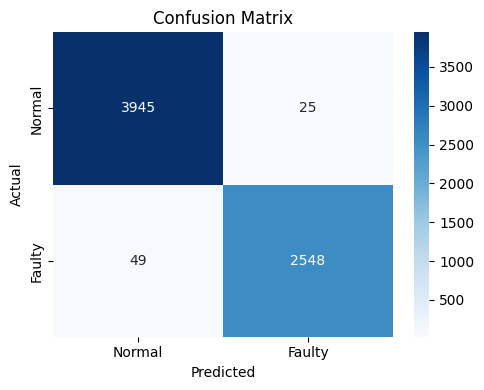

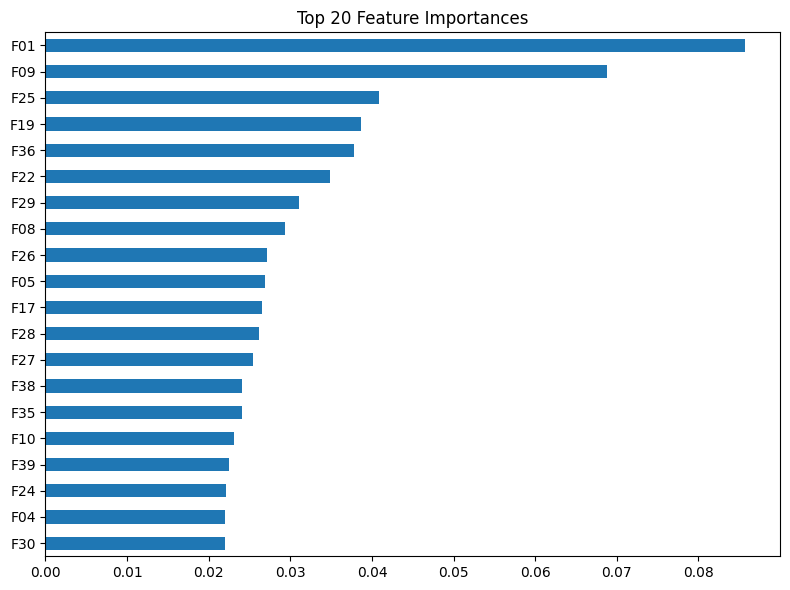


FINAL.csv saved to: /content/drive/MyDrive/ML Challenge Dataset/FINAL.csv
Total predictions: 10944

Sample output:
    ID  CLASS
0   1      1
1   2      0
2   3      1
3   4      0
4   5      0
5   6      1
6   7      0
7   8      1
8   9      1
9  10      0

Prediction distribution:
 CLASS
0    6686
1    4258
Name: count, dtype: int64


In [17]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_PATH = "/content/drive/MyDrive/ML Challenge Dataset/TRAIN.csv"
TEST_PATH  = "/content/drive/MyDrive/ML Challenge Dataset/TEST.csv"
OUTPUT_PATH = "/content/drive/MyDrive/ML Challenge Dataset/FINAL.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nClass distribution:\n", train['Class'].value_counts())
print("\nClass balance %:\n", train['Class'].value_counts(normalize=True).mul(100).round(2))

X = train.drop(columns=['Class'])
y = train['Class']

test_ids = test['ID']
X_test   = test.drop(columns=['ID'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=40,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print("\n--- Validation Results ---")
print(f"Accuracy : {accuracy_score(y_val, y_pred) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred,
      target_names=['Normal (0)', 'Faulty (1)']))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Faulty'],
            yticklabels=['Normal', 'Faulty'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top20.plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

test_preds = model.predict(X_test)

final = pd.DataFrame({'ID': test_ids, 'CLASS': test_preds})
final.to_csv(OUTPUT_PATH, index=False)

print(f"\nFINAL.csv saved to: {OUTPUT_PATH}")
print(f"Total predictions: {len(final)}")
print("\nSample output:\n", final.head(10))
print("\nPrediction distribution:\n", final['CLASS'].value_counts())